# **1. Cài đặt môi trường**

In [ ]:
!pip install pyspark pandas numpy matplotlib -q

# **2. Kết nối Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **3. Import thư viện**

In [ ]:
import os
import time
import shutil
import pandas as pd
import numpy as np

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, avg, count, first, when, lit, coalesce,
    concat_ws, rand, desc, row_number, collect_set, explode, array, struct
)
from pyspark.sql.types import (
    StructType, StructField, StringType, DoubleType,
    LongType, BooleanType, ArrayType
)
from pyspark.sql.window import Window

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator

import matplotlib.pyplot as plt

# **4. Khởi tạo Spark**

In [ ]:
spark = SparkSession.builder \
    .appName("ALS_Hybrid_Recommendation") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

print("Spark master:", spark.sparkContext.master)
print("Default parallelism:", spark.sparkContext.defaultParallelism)
print("Spark version:", spark.version)

Spark master: local[*]
Default parallelism: 2
Spark version: 4.0.2


# **5. Khai báo đường dẫn thư mục trên GG Drive**

In [ ]:
base_path = "/content/drive/MyDrive/ALS_Hybrid_Recommendation"

raw_path = base_path + "/data/raw"
processed_path = base_path + "/data/processed"
results_path = base_path + "/data/results"
charts_path = results_path + "/charts"

reviews_path = raw_path + "/Arts_Crafts_and_Sewing_5.json.gz"
meta_path = raw_path + "/meta_Arts_Crafts_and_Sewing.json.gz"

# Các bảng Parquet dùng cho luồng lưu trữ/xử lý phân tán
raw_reviews_parquet_path = processed_path + "/raw_reviews_parquet"
raw_meta_parquet_path = processed_path + "/raw_meta_parquet"
cleaned_parquet_path = processed_path + "/cleaned_interactions_parquet"
indexed_parquet_path = processed_path + "/indexed_interactions_parquet"

topk_als_path = results_path + "/topk_als_recommendations_parquet"
topk_hybrid_path = results_path + "/topk_hybrid_recommendations_parquet"
cold_start_path = results_path + "/cold_start_fallback_parquet"
popular_by_brand_path = results_path + "/cold_start_by_brand_parquet"
popular_by_category_path = results_path + "/cold_start_by_category_parquet"

os.makedirs(raw_path, exist_ok=True)
os.makedirs(processed_path, exist_ok=True)
os.makedirs(results_path, exist_ok=True)
os.makedirs(charts_path, exist_ok=True)

print("Reviews path:", reviews_path)
print("Metadata path:", meta_path)
print("Processed path:", processed_path)
print("Results path:", results_path)
print("Charts path:", charts_path)


Reviews path: /content/drive/MyDrive/ALS_Hybrid_Recommendation/data/raw/Arts_Crafts_and_Sewing_5.json.gz
Metadata path: /content/drive/MyDrive/ALS_Hybrid_Recommendation/data/raw/meta_Arts_Crafts_and_Sewing.json.gz
Processed path: /content/drive/MyDrive/ALS_Hybrid_Recommendation/data/processed
Results path: /content/drive/MyDrive/ALS_Hybrid_Recommendation/data/results
Charts path: /content/drive/MyDrive/ALS_Hybrid_Recommendation/data/results/charts


# **6. Đọc dữ liệu JSON bằng schema riêng**

6.1. Khai báo schema để đọc JSON

In [ ]:
reviews_schema = StructType([
    StructField("reviewerID", StringType(), True),
    StructField("asin", StringType(), True),
    StructField("overall", DoubleType(), True)
])

meta_schema = StructType([
    StructField("asin", StringType(), True),
    StructField("title", StringType(), True),
    StructField("brand", StringType(), True),
    StructField("category", ArrayType(StringType()), True)
])

6.2. Đọc 2 file JSON

In [ ]:
start_time = time.time()

reviews_raw = spark.read.schema(reviews_schema).json(reviews_path)
meta_raw = spark.read.schema(meta_schema).json(meta_path)

json_read_time = time.time() - start_time

print("Thời gian đọc file dạng JSON:", round(json_read_time, 3), "seconds")

print("Reviews schema:")
reviews_raw.printSchema()

print("Metadata schema:")
meta_raw.printSchema()

Thời gian đọc file dạng JSON: 2.833 seconds
Reviews schema:
root
 |-- reviewerID: string (nullable = true)
 |-- asin: string (nullable = true)
 |-- overall: double (nullable = true)

Metadata schema:
root
 |-- asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- category: array (nullable = true)
 |    |-- element: string (containsNull = true)



# **7. Đọc dữ liệu Parquet**

7.1. Ghi raw JSON sang Parquet

In [ ]:
raw_reviews_parquet_path = processed_path + "/raw_reviews_parquet"
raw_meta_parquet_path = processed_path + "/raw_meta_parquet"

reviews_raw.write.mode("overwrite").parquet(raw_reviews_parquet_path)
meta_raw.write.mode("overwrite").parquet(raw_meta_parquet_path)

7.2. So sánh tốc độ đọc reviews JSON và reviews Parquet

In [ ]:
start_time = time.time()
json_test_df = spark.read.schema(reviews_schema).json(reviews_path)
json_count = json_test_df.count()
json_time = time.time() - start_time

start_time = time.time()
parquet_test_df = spark.read.parquet(raw_reviews_parquet_path)
parquet_count = parquet_test_df.count()
parquet_time = time.time() - start_time

print("JSON rows:", json_count)
print("Parquet rows:", parquet_count)
print("JSON read time:", round(json_time, 3), "seconds")
print("Parquet read time:", round(parquet_time, 3), "seconds")

if parquet_time > 0:
    print("Parquet speedup:", round(json_time / parquet_time, 2), "x")

JSON rows: 494485
Parquet rows: 494485
JSON read time: 3.457 seconds
Parquet read time: 0.756 seconds
Parquet speedup: 4.57 x


7.3. Biểu đồ so sánh thời gian đọc JSON với Parquet

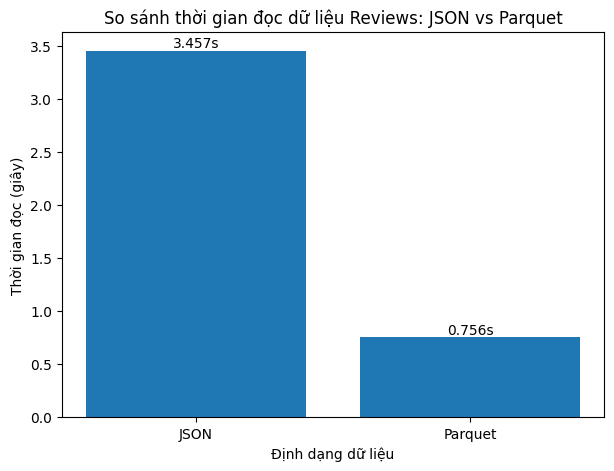

JSON read time: 3.457 seconds
Parquet read time: 0.756 seconds
Parquet nhanh hơn JSON khoảng: 4.57 lần
Đã lưu biểu đồ tại: /content/drive/MyDrive/ALS_Hybrid_Recommendation/data/results/charts/json_vs_parquet_read_time.png


In [ ]:
chart_path = charts_path + "/json_vs_parquet_read_time.png"

formats = ["JSON", "Parquet"]
read_times = [json_time, parquet_time]

plt.figure(figsize=(7, 5))
bars = plt.bar(formats, read_times)

plt.title("So sánh thời gian đọc dữ liệu Reviews: JSON vs Parquet")
plt.xlabel("Định dạng dữ liệu")
plt.ylabel("Thời gian đọc (giây)")

for bar, time_value in zip(bars, read_times):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{time_value:.3f}s",
        ha="center",
        va="bottom"
    )

plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("JSON read time:", round(json_time, 3), "seconds")
print("Parquet read time:", round(parquet_time, 3), "seconds")

if parquet_time > 0:
    print("Parquet nhanh hơn JSON khoảng:", round(json_time / parquet_time, 2), "lần")

print("Đã lưu biểu đồ tại:", chart_path)

7.4. Hàm hỗ trợ đo dung lượng file/thư mục

In [ ]:
def get_size_mb(path):
    total_size = 0

    if os.path.isfile(path):
        total_size = os.path.getsize(path)

    elif os.path.isdir(path):
        for dirpath, dirnames, filenames in os.walk(path):
            for filename in filenames:
                file_path = os.path.join(dirpath, filename)
                if os.path.exists(file_path):
                    total_size += os.path.getsize(file_path)

    return total_size / (1024 * 1024)

print("Đã tạo hàm get_size_mb()")

Đã tạo hàm get_size_mb()


7.5. So sánh dung lượng lưu trữ JSON.GZ và Parquet

,Định dạng,Dung lượng MB
0,JSON.GZ,51.60
1,Parquet,2.42


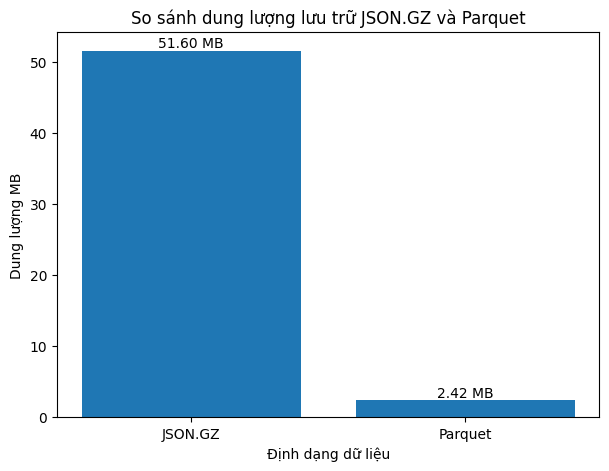

Dung lượng JSON.GZ: 51.6 MB
Dung lượng Parquet: 2.42 MB
Đã lưu biểu đồ tại: /content/drive/MyDrive/ALS_Hybrid_Recommendation/data/results/charts/json_vs_parquet_storage_size.png


In [ ]:
json_size_mb = get_size_mb(reviews_path)
parquet_size_mb = get_size_mb(raw_reviews_parquet_path)

storage_compare = pd.DataFrame({
    "Định dạng": ["JSON.GZ", "Parquet"],
    "Dung lượng MB": [
        round(json_size_mb, 2),
        round(parquet_size_mb, 2)
    ]
})

display(storage_compare)

plt.figure(figsize=(7, 5))
bars = plt.bar(storage_compare["Định dạng"], storage_compare["Dung lượng MB"])

plt.title("So sánh dung lượng lưu trữ JSON.GZ và Parquet")
plt.xlabel("Định dạng dữ liệu")
plt.ylabel("Dung lượng MB")

for bar, value in zip(bars, storage_compare["Dung lượng MB"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f} MB",
        ha="center",
        va="bottom"
    )

storage_chart_path = charts_path + "/json_vs_parquet_storage_size.png"
plt.savefig(storage_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Dung lượng JSON.GZ:", round(json_size_mb, 2), "MB")
print("Dung lượng Parquet:", round(parquet_size_mb, 2), "MB")
print("Đã lưu biểu đồ tại:", storage_chart_path)

# **8. Chọn cột cần dùng và làm sạch dữ liệu**

8.1. Đọc raw Parquet để làm sạch dữ liệu

In [ ]:
reviews_raw_for_clean = spark.read.parquet(raw_reviews_parquet_path)

print("Schema Reviews dùng để clean:")
reviews_raw_for_clean.printSchema()

print("Số dòng Reviews raw Parquet:", reviews_raw_for_clean.count())

reviews_raw_for_clean.show(5, truncate=False)

Schema Reviews dùng để clean:
root
 |-- reviewerID: string (nullable = true)
 |-- asin: string (nullable = true)
 |-- overall: double (nullable = true)

Số dòng Reviews raw Parquet: 494485
+--------------+----------+-------+
|reviewerID    |asin      |overall|
+--------------+----------+-------+
|AIE8N9U317ZBM |0449819906|4.0    |
|A3ECOW0TWLH9V6|0449819906|5.0    |
|A278N8QX9TY2OS|0449819906|4.0    |
|A123W8HIK76XCN|0449819906|5.0    |
|A2A6MZ2QB4AE0L|0449819906|5.0    |
+--------------+----------+-------+
only showing top 5 rows


8.2. Chọn cột cần thiết


*   Với reviews chỉ lấy: reviewerID, asin, overall
*   Với metadata chỉ lấy: asin, title, brand, category

In [ ]:
reviews_df = reviews_raw_for_clean.select(
    col("reviewerID"),
    col("asin"),
    col("overall").alias("rating")
)

meta_df = meta_raw.select(
    col("asin"),
    col("title"),
    col("brand"),
    col("category")
)

print("Reviews sau khi chọn cột:")
reviews_df.show(5, truncate=False)

print("Metadata sau khi chọn cột:")
meta_df.show(5, truncate=False)

Reviews sau khi chọn cột:
+--------------+----------+------+
|reviewerID    |asin      |rating|
+--------------+----------+------+
|AIE8N9U317ZBM |0449819906|4.0   |
|A3ECOW0TWLH9V6|0449819906|5.0   |
|A278N8QX9TY2OS|0449819906|4.0   |
|A123W8HIK76XCN|0449819906|5.0   |
|A2A6MZ2QB4AE0L|0449819906|5.0   |
+--------------+----------+------+
only showing top 5 rows
Metadata sau khi chọn cột:
+----------+----------------------------------------------------------------------------------------------------+----------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|asin      |title                            

8.3. Làm sạch dữ liệu Reviews (5-core)
*   Bỏ dòng thiếu reviewerID, asin, rating
*   Chỉ giữ rating từ 1 đến 5
*   Nếu một user đánh giá cùng một sản phẩm nhiều lần thì lấy rating trung bình, không dùng dropDuplicates ngẫu nhiên.

In [ ]:
reviews_before_clean = reviews_df.count()

reviews_df = reviews_df.dropna(subset=["reviewerID", "asin", "rating"])

reviews_df = reviews_df.filter(
    (col("rating") >= 1.0) & (col("rating") <= 5.0)
)

# Gom nhóm theo user-item để tránh trùng rating
reviews_df = reviews_df.groupBy("reviewerID", "asin").agg(
    avg("rating").alias("rating"),
    count("*").alias("interaction_count")
)

reviews_after_clean = reviews_df.count()

print("Số dòng Reviews trước khi clean:", reviews_before_clean)
print("Số dòng Reviews sau khi clean:", reviews_after_clean)
print("Số dòng bị loại/gom:", reviews_before_clean - reviews_after_clean)

print("\nMẫu Reviews sau khi clean:")
reviews_df.show(10, truncate=False)

Số dòng Reviews trước khi clean: 494485
Số dòng Reviews sau khi clean: 440318
Số dòng bị loại/gom: 54167

Mẫu Reviews sau khi clean:
+--------------+----------+------+-----------------+
|reviewerID    |asin      |rating|interaction_count|
+--------------+----------+------+-----------------+
|A1EWCPZ3FKLGLL|048625531X|5.0   |1                |
|A2OW65JIXYDXCJ|0715329278|3.0   |1                |
|A1W7XY6RWHW7AF|0823013626|5.0   |1                |
|A1INFXPGZVFLZB|0823013626|5.0   |1                |
|AYYLXBHICSIZ4 |0848724666|5.0   |1                |
|A3K1A3MUYKQ9B9|0848724666|5.0   |1                |
|AZHZV2EAXV37R |0848724666|4.0   |1                |
|A1I13MX0GHA8CN|0848734270|5.0   |1                |
|A14SGOHVW0XOZ5|0887248845|5.0   |1                |
|A39AYI5050J67T|0887248845|5.0   |1                |
+--------------+----------+------+-----------------+
only showing top 10 rows


8.4. Làm sạch dữ liệu Metadata
*   Bỏ dòng thiếu asin
*   Nếu metadata có nhiều dòng cùng một asin thì gom lại
*   Điền giá trị thiếu bằng Unknown

In [ ]:
meta_before_clean = meta_df.count()

meta_df = meta_df.dropna(subset=["asin"])

# Gom theo asin, lấy giá trị đầu tiên không null
meta_df = meta_df.groupBy("asin").agg(
    first("title", ignorenulls=True).alias("title"),
    first("brand", ignorenulls=True).alias("brand"),
    first("category", ignorenulls=True).alias("category")
)

# Điền giá trị thiếu
meta_df = meta_df.withColumn(
    "title",
    coalesce(col("title"), lit("Unknown product"))
).withColumn(
    "brand",
    coalesce(col("brand"), lit("Unknown brand"))
).withColumn(
    "category",
    when(col("category").isNull(), array(lit("Unknown category"))).otherwise(col("category"))
)

meta_after_clean = meta_df.count()

print("Số dòng Metadata trước khi clean:", meta_before_clean)
print("Số dòng Metadata sau khi clean:", meta_after_clean)
print("Số dòng Metadata bị loại/gom:", meta_before_clean - meta_after_clean)

print("\nMẫu Metadata sau khi clean:")
meta_df.show(10, truncate=False)

Số dòng Metadata trước khi clean: 302988
Số dòng Metadata sau khi clean: 302380
Số dòng Metadata bị loại/gom: 608

Mẫu Metadata sau khi clean:
+----------+----------------------------------------------------------------------------------------------------------------------------+----------------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|asin      |title                                                                                                                       |brand                                               |category                                    

8.5. Tổng quan dữ liệu sau khi làm sạch

In [ ]:
print("Số lượng Reviews sau làm sạch:", reviews_df.count())
print("Số lượng Metadata sau làm sạch:", meta_df.count())

print("Số users:", reviews_df.select("reviewerID").distinct().count())
print("Số items trong reviews:", reviews_df.select("asin").distinct().count())
print("Số items trong metadata:", meta_df.select("asin").distinct().count())

print("\nPhân phối rating sau clean:")
reviews_df.groupBy("rating").count().orderBy("rating").show()

Số lượng Reviews sau làm sạch: 440318
Số lượng Metadata sau làm sạch: 302380
Số users: 56210
Số items trong reviews: 22931
Số items trong metadata: 302380

Phân phối rating sau clean:
+------------------+-----+
|            rating|count|
+------------------+-----+
|               1.0|12749|
|               1.2|    1|
|              1.25|    1|
|               1.4|    1|
|               1.5|   22|
|1.6666666666666667|    2|
|               2.0|11395|
|2.3333333333333335|    1|
|               2.4|    1|
|               2.5|   34|
|               2.6|    1|
|2.6666666666666665|    1|
|              2.75|    1|
|               3.0|25516|
|              3.25|    4|
|3.3333333333333335|   15|
|               3.5|  117|
|3.6666666666666665|   21|
|              3.75|    4|
|               4.0|54365|
+------------------+-----+
only showing top 20 rows


8.6. Join review với metadata bằng asin

In [ ]:
data_df = reviews_df.join(
    meta_df,
    on="asin",
    how="left"
)

# Sau khi join, nếu sản phẩm không có metadata thì điền Unknown
data_df = data_df.withColumn(
    "title",
    coalesce(col("title"), lit("Unknown product"))
).withColumn(
    "brand",
    coalesce(col("brand"), lit("Unknown brand"))
).withColumn(
    "category",
    when(col("category").isNull(), array(lit("Unknown category"))).otherwise(col("category"))
)

data_count = data_df.count()

print("Số dòng sau khi join Reviews + Metadata:", data_count)

data_df.show(10, truncate=False)

Số dòng sau khi join Reviews + Metadata: 440318
+----------+--------------+------+-----------------+---------------+-------------+------------------+
|asin      |reviewerID    |rating|interaction_count|title          |brand        |category          |
+----------+--------------+------+-----------------+---------------+-------------+------------------+
|048625531X|A1EWCPZ3FKLGLL|5.0   |1                |Unknown product|Unknown brand|[Unknown category]|
|0715329278|A2OW65JIXYDXCJ|3.0   |1                |Unknown product|Unknown brand|[Unknown category]|
|0715329278|AF2J5J39XFNQR |5.0   |1                |Unknown product|Unknown brand|[Unknown category]|
|0715329278|A3NL76I57WEEJL|5.0   |1                |Unknown product|Unknown brand|[Unknown category]|
|0848724666|AYYLXBHICSIZ4 |5.0   |1                |Unknown product|Unknown brand|[Unknown category]|
|0848724666|A3K1A3MUYKQ9B9|5.0   |1                |Unknown product|Unknown brand|[Unknown category]|
|0848724666|AZHZV2EAXV37R |4.0   |

8.7. Kiểm tra dữ liệu Unknown sau join

In [ ]:
unknown_stats = data_df.select(
    count("*").alias("total_rows"),
    count(when(col("title") == "Unknown product", True)).alias("unknown_title_rows"),
    count(when(col("brand") == "Unknown brand", True)).alias("unknown_brand_rows"),
    count(when(concat_ws(" ", col("category")) == "Unknown category", True)).alias("unknown_category_rows")
)

unknown_stats.show(truncate=False)

+----------+------------------+------------------+---------------------+
|total_rows|unknown_title_rows|unknown_brand_rows|unknown_category_rows|
+----------+------------------+------------------+---------------------+
|440318    |1402              |1402              |1402                 |
+----------+------------------+------------------+---------------------+



8.8. Lưu dữ liệu đã clean + join sang Parquet

In [ ]:
data_df.write.mode("overwrite").parquet(cleaned_parquet_path)

start_time = time.time()

data_df = spark.read.parquet(cleaned_parquet_path)
cleaned_count = data_df.count()

cleaned_parquet_time = time.time() - start_time

print("Số dòng đọc từ cleaned Parquet:", cleaned_count)
print("Thời gian đọc cleaned Parquet:", round(cleaned_parquet_time, 3), "seconds")

print("\nMẫu dữ liệu sau khi đọc lại từ cleaned Parquet:")
data_df.show(10, truncate=False)

Số dòng đọc từ cleaned Parquet: 440318
Thời gian đọc cleaned Parquet: 0.443 seconds

Mẫu dữ liệu sau khi đọc lại từ cleaned Parquet:
+----------+--------------+------+-----------------+---------------+-------------+------------------+
|asin      |reviewerID    |rating|interaction_count|title          |brand        |category          |
+----------+--------------+------+-----------------+---------------+-------------+------------------+
|0449819906|A3ECOW0TWLH9V6|5.0   |1                |Unknown product|Unknown brand|[Unknown category]|
|0449819906|A2A6MZ2QB4AE0L|5.0   |1                |Unknown product|Unknown brand|[Unknown category]|
|0449819906|A278N8QX9TY2OS|4.0   |1                |Unknown product|Unknown brand|[Unknown category]|
|0449819906|A2BQ7YGPNCQSO4|4.0   |1                |Unknown product|Unknown brand|[Unknown category]|
|0449819906|A2OIU84NPVKIWN|5.0   |1                |Unknown product|Unknown brand|[Unknown category]|
|0449819906|A24ZH91LIJ3DKX|5.0   |1                

# **9. Index user và item cho ALS**

In [ ]:
# Đảm bảo có category_str trước khi index
if "category_str" not in data_df.columns:
    data_df = data_df.withColumn(
        "category_str",
        concat_ws(" > ", col("category"))
    )

user_indexer = StringIndexer(
    inputCol="reviewerID",
    outputCol="userIndex",
    handleInvalid="keep"
)

item_indexer = StringIndexer(
    inputCol="asin",
    outputCol="itemIndex",
    handleInvalid="keep"
)

pipeline = Pipeline(stages=[user_indexer, item_indexer])

index_model = pipeline.fit(data_df)

als_df = index_model.transform(data_df)

als_df = als_df.withColumn("userIndex", col("userIndex").cast("int")) \
               .withColumn("itemIndex", col("itemIndex").cast("int")) \
               .withColumn("rating", col("rating").cast("double"))

als_df = als_df.select(
    "reviewerID",
    "asin",
    "userIndex",
    "itemIndex",
    "rating",
    "title",
    "brand",
    "category",
    "category_str"
)

als_df = als_df.repartition(8)

print("Số partition trước khi ghi Parquet:", als_df.rdd.getNumPartitions())

als_df.write.mode("overwrite").parquet(indexed_parquet_path)

als_df = spark.read.parquet(indexed_parquet_path)

print("Đã lưu indexed interactions:", indexed_parquet_path)
print("Số dòng ALS data:", als_df.count())
print("Số partition ALS data (sau khi đọc lại Parquet):", als_df.rdd.getNumPartitions())

print("Dữ liệu sau khi index:")
als_df.show(10, truncate=False)

print("\nSchema sau khi index:")
als_df.printSchema()

Số partition trước khi ghi Parquet: 8
Đã lưu indexed interactions: /content/drive/MyDrive/ALS_Hybrid_Recommendation/data/processed/indexed_interactions_parquet
Số dòng ALS data: 440318
Số partition ALS data (sau khi đọc lại Parquet): 2
Dữ liệu sau khi index:
+--------------+----------+---------+---------+------+---------------------------------------------------------------------------------------------------+------------------+---------------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------------+
|reviewerID    |asin      |userIndex|itemIndex|rating|title                                                                                              |brand             |category                                                                                                 |category_str                                                               

# **10. Kiểm tra dữ liệu sau index và partition**

10.1. Kiểm tra dữ liệu sau index

In [ ]:
als_count = als_df.count()
indexed_users = als_df.select("userIndex").distinct().count()
indexed_items = als_df.select("itemIndex").distinct().count()

print("Số dòng dùng cho ALS:", als_count)
print("Số userIndex:", indexed_users)
print("Số itemIndex:", indexed_items)

Số dòng dùng cho ALS: 440318
Số userIndex: 56210
Số itemIndex: 22931


10.2. Kiểm tra partition

,DataFrame,Số partition
0,reviews_raw,1
1,meta_raw,1
2,reviews_df,3
3,meta_df,2
4,data_df_cleaned,2
5,als_df_indexed,2


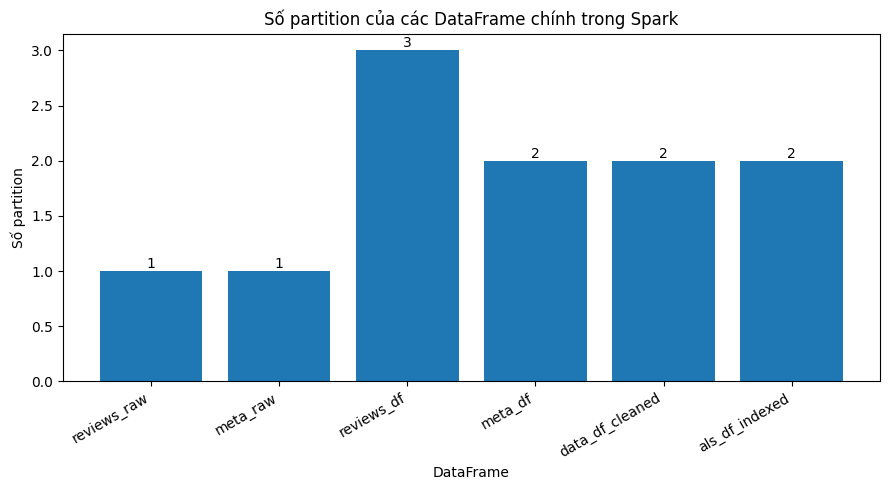

Đã lưu biểu đồ: /content/drive/MyDrive/ALS_Hybrid_Recommendation/data/results/charts/spark_dataframe_partitions.png


In [ ]:
partition_info = pd.DataFrame({
    "DataFrame": [
        "reviews_raw",
        "meta_raw",
        "reviews_df",
        "meta_df",
        "data_df_cleaned",
        "als_df_indexed"
    ],
    "Số partition": [
        reviews_raw.rdd.getNumPartitions(),
        meta_raw.rdd.getNumPartitions(),
        reviews_df.rdd.getNumPartitions(),
        meta_df.rdd.getNumPartitions(),
        data_df.rdd.getNumPartitions(),
        als_df.rdd.getNumPartitions()
    ]
})

display(partition_info)

plt.figure(figsize=(9, 5))
bars = plt.bar(partition_info["DataFrame"], partition_info["Số partition"])

plt.title("Số partition của các DataFrame chính trong Spark")
plt.xlabel("DataFrame")
plt.ylabel("Số partition")

for bar, value in zip(bars, partition_info["Số partition"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(value),
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

partition_chart_path = charts_path + "/spark_dataframe_partitions.png"
plt.savefig(partition_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Đã lưu biểu đồ:", partition_chart_path)

# **11. Chia train / validation / test**

In [ ]:
# Chia dữ liệu thành train / validation / test với tỷ lệ 70/10/20
train_df, valid_df, test_df = als_df.randomSplit([0.7, 0.1, 0.2], seed=42)

train_count = train_df.count()
valid_count = valid_df.count()
test_count = test_df.count()

total_split_count = train_count + valid_count + test_count

print("Train rows:", train_count)
print("Validation rows:", valid_count)
print("Test rows:", test_count)

print("\nTổng sau khi chia:", total_split_count)
print("Tổng ban đầu:", als_df.count())

print("\nTỷ lệ train:", round(train_count / total_split_count * 100, 2), "%")
print("Tỷ lệ validation:", round(valid_count / total_split_count * 100, 2), "%")
print("Tỷ lệ test:", round(test_count / total_split_count * 100, 2), "%")

Train rows: 308109
Validation rows: 43965
Test rows: 88244

Tổng sau khi chia: 440318
Tổng ban đầu: 440318

Tỷ lệ train: 69.97 %
Tỷ lệ validation: 9.98 %
Tỷ lệ test: 20.04 %


# **12. Tạo hàm đánh giá RMSE**

In [ ]:
def clamp_prediction(df, input_col="prediction", output_col="prediction_clamped"):
    return df.withColumn(
        output_col,
        when(col(input_col) < 1.0, 1.0)
        .when(col(input_col) > 5.0, 5.0)
        .otherwise(col(input_col))
    )

evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction_clamped"
)

print("Đã tạo hàm đánh giá RMSE")

Đã tạo hàm đánh giá RMSE


# **13. Khởi tạo ALS**

In [ ]:
als = ALS(
    userCol="userIndex",
    itemCol="itemIndex",
    ratingCol="rating",
    coldStartStrategy="drop",
    nonnegative=True,
    implicitPrefs=False,
    rank=10,
    maxIter=10,
    regParam=0.1,
    seed=42
)

print("Đã khởi tạo mô hình ALS")

Đã khởi tạo mô hình ALS


# **14. Train ALS**

14.1. Train ALS không cache

In [ ]:
# Huấn luyện mô hình ALS không sử dụng cache
start_time = time.time()

als_model_no_cache = als.fit(train_df)

als_no_cache_time = time.time() - start_time

print("Thời gian train ALS không cache:", round(als_no_cache_time, 3), "seconds")

Thời gian train ALS không cache: 46.591 seconds


14.2. Cache train / validation / test

In [ ]:
# Cache dữ liệu để tối ưu quá trình huấn luyện
train_cached = train_df.cache()
valid_cached = valid_df.cache()
test_cached = test_df.cache()

train_cached.count()
valid_cached.count()
test_cached.count()

print("Đã cache train / validation / test")

Đã cache train / validation / test


14.3. Train ALS có cache

In [ ]:
# Huấn luyện mô hình ALS có sử dụng cache

start_time = time.time()

als_model_cache = als.fit(train_cached)

als_cache_time = time.time() - start_time

print("Thời gian train ALS có cache:", round(als_cache_time, 3), "seconds")

Thời gian train ALS có cache: 35.685 seconds


14.4. So sánh thời gian train ALS có cache và không cache

In [ ]:
cache_comparison = pd.DataFrame({
    "Trường hợp": [
        "ALS không cache",
        "ALS có cache"
    ],
    "Thời gian huấn luyện (giây)": [
        round(als_no_cache_time, 4),
        round(als_cache_time, 4)
    ]
})

display(cache_comparison)

if als_cache_time > 0:
    cache_speedup = als_no_cache_time / als_cache_time
    print("Cache speedup:", round(cache_speedup, 2), "x")
else:
    cache_speedup = None
    print("Không tính được speedup vì thời gian cache = 0")

,Trường hợp,Thời gian huấn luyện (giây)
0,ALS không cache,46.5911
1,ALS có cache,35.6848


Cache speedup: 1.31 x


14.5. Vẽ biểu đồ so sánh thời gian huấn luyện ALS có cache và không cache

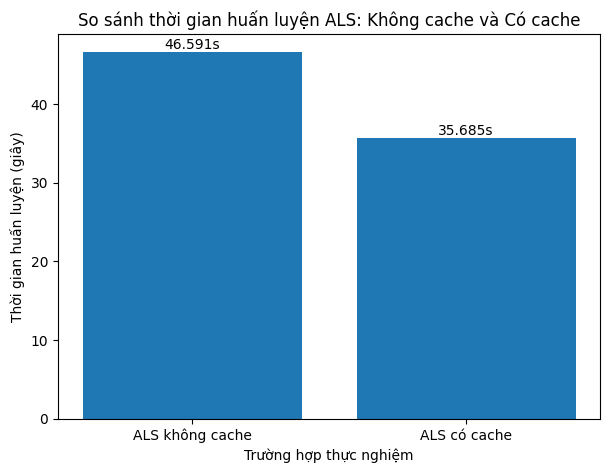

Đã lưu biểu đồ tại: /content/drive/MyDrive/ALS_Hybrid_Recommendation/data/results/charts/als_cache_training_time.png


In [ ]:
cache_formats = ["ALS không cache", "ALS có cache"]
cache_times = [als_no_cache_time, als_cache_time]

plt.figure(figsize=(7, 5))
bars = plt.bar(cache_formats, cache_times)

plt.title("So sánh thời gian huấn luyện ALS: Không cache và Có cache")
plt.xlabel("Trường hợp thực nghiệm")
plt.ylabel("Thời gian huấn luyện (giây)")

for bar, value in zip(bars, cache_times):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}s",
        ha="center",
        va="bottom"
    )

cache_chart_path = charts_path + "/als_cache_training_time.png"
plt.savefig(cache_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Đã lưu biểu đồ tại:", cache_chart_path)

14.6. Đánh giá ALS trên test

In [ ]:
pred_test_als = als_model_cache.transform(test_cached)
pred_test_als = pred_test_als.dropna(subset=["prediction"])

pred_test_als = clamp_prediction(
    pred_test_als,
    input_col="prediction",
    output_col="prediction_clamped"
)

rmse_als_test = evaluator.evaluate(pred_test_als)

print("ALS Test RMSE:", round(rmse_als_test, 4))

ALS Test RMSE: 1.0517


# **15. Xây dựng Content-based score từ train**

In [ ]:
def build_content_score(train_input_df, target_input_df):
    train_content_df = train_input_df
    target_content_df = target_input_df

    if "category_str" not in train_content_df.columns:
        train_content_df = train_content_df.withColumn("category_str", concat_ws(" > ", col("category")))

    # Chỉ lấy các sản phẩm user thích trong tập train để học sở thích nội dung.
    liked_train_df = train_content_df.filter(col("rating") >= 4.0)

    # Sở thích theo brand
    user_brand_pref = liked_train_df.groupBy("userIndex", "brand").agg(
        avg("rating").alias("brand_avg_rating"),
        count("*").alias("brand_count")
    )

    # Sở thích theo category
    user_category_pref = liked_train_df.groupBy("userIndex", "category_str").agg(
        avg("rating").alias("category_avg_rating"),
        count("*").alias("category_count")
    )

    global_avg_rating = train_input_df.agg(
        avg("rating").alias("global_avg")
    ).collect()[0]["global_avg"]

    if global_avg_rating is None:
        global_avg_rating = 3.0

    content_score_df = target_content_df.join(
        user_brand_pref,
        on=["userIndex", "brand"],
        how="left"
    ).join(
        user_category_pref,
        on=["userIndex", "category_str"],
        how="left"
    )

    content_score_df = content_score_df.withColumn(
        "brand_avg_rating",
        coalesce(col("brand_avg_rating"), lit(global_avg_rating))
    ).withColumn(
        "category_avg_rating",
        coalesce(col("category_avg_rating"), lit(global_avg_rating))
    ).withColumn(
        "content_score",
        0.5 * col("brand_avg_rating") + 0.5 * col("category_avg_rating")
    )

    return content_score_df

# **16. Chọn alpha Hybrid bằng validation**

In [ ]:
# Alpha là trọng số kết hợp: Hybrid = alpha * ALS + (1 - alpha) * Content-based

pred_valid_als = als_model_cache.transform(valid_cached)
pred_valid_als = pred_valid_als.dropna(subset=["prediction"])

content_valid = build_content_score(
    train_cached,
    valid_cached
).select(
    "userIndex",
    "itemIndex",
    "content_score"
)

hybrid_valid_base = pred_valid_als.join(
    content_valid,
    on=["userIndex", "itemIndex"],
    how="left"
)

global_train_avg = train_cached.agg(
    avg("rating").alias("global_avg")
).collect()[0]["global_avg"]

if global_train_avg is None:
    global_train_avg = 3.0

hybrid_valid_base = hybrid_valid_base.withColumn(
    "content_score",
    coalesce(col("content_score"), lit(global_train_avg))
)

alpha_values = [0.5, 0.6, 0.7, 0.8, 0.9]
alpha_results = []

for alpha in alpha_values:
    temp_df = hybrid_valid_base.withColumn(
        "hybrid_prediction",
        lit(alpha) * col("prediction") + lit(1 - alpha) * col("content_score")
    )

    temp_df = clamp_prediction(
        temp_df,
        input_col="hybrid_prediction",
        output_col="hybrid_prediction_clamped"
    )

    hybrid_evaluator = RegressionEvaluator(
        metricName="rmse",
        labelCol="rating",
        predictionCol="hybrid_prediction_clamped"
    )

    rmse = hybrid_evaluator.evaluate(temp_df)
    alpha_results.append((alpha, rmse))

alpha_results_df = pd.DataFrame(
    alpha_results,
    columns=["alpha", "validation_rmse"]
)

display(alpha_results_df)

best_alpha, best_valid_rmse = sorted(alpha_results, key=lambda x: x[1])[0]

print("Best alpha:", best_alpha)
print("Best validation RMSE:", round(best_valid_rmse, 4))

,alpha,validation_rmse
0,0.5,0.887050
1,0.6,0.906394
2,0.7,0.933279
3,0.8,0.967032
4,0.9,1.006802


Best alpha: 0.5
Best validation RMSE: 0.887


# **17. Đánh giá Hybrid trên test**

In [ ]:
content_test = build_content_score(
    train_cached,
    test_cached
).select(
    "userIndex",
    "itemIndex",
    "content_score"
)

hybrid_test = pred_test_als.join(
    content_test,
    on=["userIndex", "itemIndex"],
    how="left"
)

hybrid_test = hybrid_test.withColumn(
    "content_score",
    coalesce(col("content_score"), lit(global_train_avg))
)

hybrid_test = hybrid_test.withColumn(
    "hybrid_prediction",
    lit(best_alpha) * col("prediction") + lit(1 - best_alpha) * col("content_score")
)

hybrid_test = clamp_prediction(
    hybrid_test,
    input_col="hybrid_prediction",
    output_col="hybrid_prediction_clamped"
)

hybrid_evaluator_test = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="hybrid_prediction_clamped"
)

rmse_hybrid_test = hybrid_evaluator_test.evaluate(hybrid_test)

print("ALS Test RMSE:", round(rmse_als_test, 4))
print("Hybrid Test RMSE:", round(rmse_hybrid_test, 4))
print("Best alpha:", best_alpha)

hybrid_test.select(
    "reviewerID",
    "asin",
    "rating",
    "prediction",
    "content_score",
    "hybrid_prediction",
    "hybrid_prediction_clamped"
).show(10, truncate=False)

ALS Test RMSE: 1.0517
Hybrid Test RMSE: 0.8912
Best alpha: 0.5
+--------------------+----------+------+----------+------------------+------------------+-------------------------+
|reviewerID          |asin      |rating|prediction|content_score     |hybrid_prediction |hybrid_prediction_clamped|
+--------------------+----------+------+----------+------------------+------------------+-------------------------+
|A0490453AYGB1BAAOG64|B007AH74VO|5.0   |4.788409  |4.5664594036133375|4.677434318353299 |4.677434318353299        |
|A10K6NS5CFBDPO      |B00FR3EEDY|3.0   |3.8371391 |4.5664594036133375|4.201799266626004 |4.201799266626004        |
|A10W3F4VRYQ0X0      |B0052UMZH4|5.0   |4.198672  |4.5664594036133375|4.382565610696439 |4.382565610696439        |
|A10ZQTNG1Z56IN      |B001145BYE|5.0   |4.5586677 |5.0               |4.779333829879761 |4.779333829879761        |
|A11YKPXSBP8DL8      |B001P3VDNE|5.0   |3.9832315 |4.5664594036133375|4.274845474053983 |4.274845474053983        |
|A11YKPXS

# **18. So sánh ALS và Hybrid**

,Mô hình,Dữ liệu sử dụng,RMSE trên test
0,ALS,User - Item - Rating,1.0517
1,Hybrid ALS + Content-based,User - Item - Rating + Brand + Category,0.8912


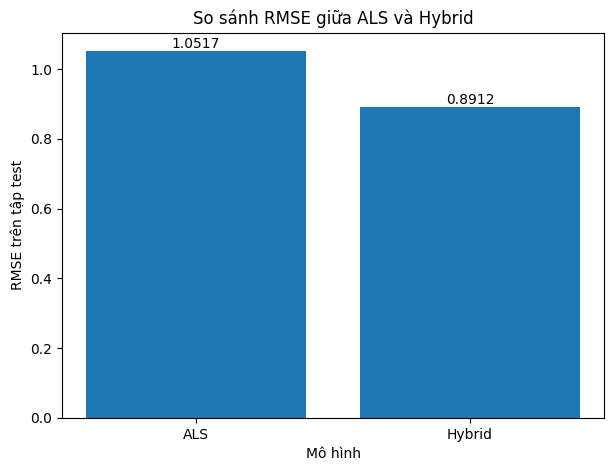

Đã lưu biểu đồ tại: /content/drive/MyDrive/ALS_Hybrid_Recommendation/data/results/charts/als_vs_hybrid_rmse.png


In [ ]:
model_comparison = pd.DataFrame({
    "Mô hình": ["ALS", "Hybrid ALS + Content-based"],
    "Dữ liệu sử dụng": [
        "User - Item - Rating",
        "User - Item - Rating + Brand + Category"
    ],
    "RMSE trên test": [
        round(rmse_als_test, 4),
        round(rmse_hybrid_test, 4)
    ]
})

display(model_comparison)

# Vẽ biểu đồ RMSE ALS vs Hybrid

model_names = ["ALS", "Hybrid"]
rmse_values = [rmse_als_test, rmse_hybrid_test]

plt.figure(figsize=(7, 5))
bars = plt.bar(model_names, rmse_values)

plt.title("So sánh RMSE giữa ALS và Hybrid")
plt.xlabel("Mô hình")
plt.ylabel("RMSE trên tập test")

for bar, value in zip(bars, rmse_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

rmse_chart_path = charts_path + "/als_vs_hybrid_rmse.png"
plt.savefig(rmse_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Đã lưu biểu đồ tại:", rmse_chart_path)

# **19. Top-K Recommendation**

19.1. Sinh Top-K Recommendation bằng ALS

In [ ]:
# Lấy top 10 sản phẩm ALS gợi ý cho mỗi user
K = 10

# Đảm bảo als_df có category_str để hiển thị danh mục dễ đọc hơn
if "category_str" not in als_df.columns:
    als_df = als_df.withColumn(
        "category_str",
        concat_ws(" > ", col("category"))
    )

# Sinh top K sản phẩm gợi ý cho tất cả user bằng mô hình ALS
user_recs_als = als_model_cache.recommendForAllUsers(K)

# Tách danh sách recommendation thành từng dòng riêng
user_recs_als_exploded = user_recs_als.select(
    col("userIndex"),
    explode(col("recommendations")).alias("rec")
).select(
    col("userIndex"),
    col("rec.itemIndex").alias("itemIndex"),
    col("rec.rating").alias("als_score")
)

# Đưa als_score về thang điểm hợp lệ từ 1 đến 5
user_recs_als_exploded = user_recs_als_exploded.withColumn(
    "als_score_clamped",
    when(col("als_score") < 1.0, 1.0)
    .when(col("als_score") > 5.0, 5.0)
    .otherwise(col("als_score"))
)

# Tạo bảng tra cứu thông tin sản phẩm
item_lookup = als_df.select(
    "itemIndex",
    "asin",
    "title",
    "brand",
    "category",
    "category_str"
).dropDuplicates(["itemIndex"])

# Tạo bảng tra cứu thông tin user gốc
user_lookup = als_df.select(
    "userIndex",
    "reviewerID"
).dropDuplicates(["userIndex"])

# Join kết quả gợi ý với thông tin sản phẩm và user
topk_als = user_recs_als_exploded.join(
    item_lookup,
    on="itemIndex",
    how="left"
).join(
    user_lookup,
    on="userIndex",
    how="left"
)

# Gắn nhãn mô hình
topk_als = topk_als.withColumn("model_type", lit("ALS"))

print("Top-K Recommendation bằng ALS:")

# Hiển thị kết quả gợi ý
topk_als.select(
    "reviewerID",
    "asin",
    "title",
    "brand",
    "category_str",
    "als_score",
    "als_score_clamped",
    "model_type"
).show(30, truncate=False)

Top-K Recommendation bằng ALS:
+--------------+----------+------------------------------------------------------------------------------------------------------------------------------------+----------------------------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+-----------------+----------+
|reviewerID    |asin      |title                                                                                                                               |brand                                   |category_str                                                                                                             

19.2. Lưu Top-K ALS Recommendation

In [ ]:
topk_als.write.mode("overwrite").parquet(topk_als_path)

print("Đã lưu Top-K ALS Recommendation tại:", topk_als_path)

Đã lưu Top-K ALS Recommendation tại: /content/drive/MyDrive/ALS_Hybrid_Recommendation/data/results/topk_als_recommendations_parquet


19.3. Sinh Top-K Recommendation bằng Hybrid

In [ ]:
# Hybrid cần kết hợp: ALS score + Content score
# Lấy nhiều ứng viên hơn từ ALS, sau đó dùng Hybrid để xếp hạng lại.

K_FINAL = 10
K_CANDIDATE = 50

# Lấy 50 ứng viên từ ALS cho mỗi user
user_recs_candidate = als_model_cache.recommendForAllUsers(K_CANDIDATE)

candidate_df = user_recs_candidate.select(
    col("userIndex"),
    explode(col("recommendations")).alias("rec")
).select(
    col("userIndex"),
    col("rec.itemIndex").alias("itemIndex"),
    col("rec.rating").alias("als_score")
)

# Ép ALS score về thang 1 -> 5 để dùng cho Hybrid
candidate_df = candidate_df.withColumn(
    "als_score_clamped",
    when(col("als_score") < 1.0, 1.0)
    .when(col("als_score") > 5.0, 5.0)
    .otherwise(col("als_score"))
)

# Join thông tin sản phẩm và user
candidate_df = candidate_df.join(
    item_lookup,
    on="itemIndex",
    how="left"
).join(
    user_lookup,
    on="userIndex",
    how="left"
)

# Tính content_score cho các candidate dựa trên train
content_candidate = build_content_score(
    train_cached,
    candidate_df
).select(
    "userIndex",
    "itemIndex",
    "content_score"
)

# Join ALS candidate với content_score
hybrid_candidate = candidate_df.join(
    content_candidate,
    on=["userIndex", "itemIndex"],
    how="left"
)

# Nếu content_score bị thiếu thì thay bằng trung bình rating của train
hybrid_candidate = hybrid_candidate.withColumn(
    "content_score",
    coalesce(col("content_score"), lit(global_train_avg))
)

# Ép content_score về thang 1 -> 5
hybrid_candidate = hybrid_candidate.withColumn(
    "content_score_clamped",
    when(col("content_score") < 1.0, 1.0)
    .when(col("content_score") > 5.0, 5.0)
    .otherwise(col("content_score"))
)

# Tính điểm Hybrid bằng best_alpha
# Dùng als_score_clamped và content_score_clamped để điểm cuối hợp lý trong thang 1 -> 5
hybrid_candidate = hybrid_candidate.withColumn(
    "hybrid_score",
    lit(best_alpha) * col("als_score_clamped")
    + lit(1 - best_alpha) * col("content_score_clamped")
)

# Ép Hybrid score về thang 1 -> 5
hybrid_candidate = hybrid_candidate.withColumn(
    "hybrid_score_clamped",
    when(col("hybrid_score") < 1.0, 1.0)
    .when(col("hybrid_score") > 5.0, 5.0)
    .otherwise(col("hybrid_score"))
)

# Chọn Top-K theo hybrid_score_clamped cho từng user
window_user = Window.partitionBy("userIndex").orderBy(desc("hybrid_score_clamped"))

topk_hybrid = hybrid_candidate.withColumn(
    "rank",
    row_number().over(window_user)
).filter(
    col("rank") <= K_FINAL
)

topk_hybrid = topk_hybrid.withColumn("model_type", lit("Hybrid ALS + Content-based"))

print("Top-K Recommendation bằng Hybrid:")

topk_hybrid.select(
    "reviewerID",
    "asin",
    "title",
    "brand",
    "category_str",
    "als_score",
    "als_score_clamped",
    "content_score",
    "content_score_clamped",
    "hybrid_score",
    "hybrid_score_clamped",
    "rank",
    "model_type"
).orderBy("userIndex", "rank").show(30, truncate=False)

Top-K Recommendation bằng Hybrid:
+--------------+----------+-------------------------------------------------------------------------------------------------------------------------------------------------------------+--------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

19.4. Lưu Top-K Hybrid Recommendation

In [ ]:
topk_hybrid.write.mode("overwrite").parquet(topk_hybrid_path)

print("Đã lưu Top-K Hybrid Recommendation tại:", topk_hybrid_path)

Đã lưu Top-K Hybrid Recommendation tại: /content/drive/MyDrive/ALS_Hybrid_Recommendation/data/results/topk_hybrid_recommendations_parquet


19.5. Biểu đồ Top brand trong gợi ý Hybrid

,brand,count
0,Bucilla,19231
1,Darice,18787
2,DECORA,14637
3,Poets Paint Waterglass Paint,11234
4,Woodland Scenics,9242
5,PH PandaHall,8481
6,Wirezoll,8313
7,Ad-Tech,8005
8,Dritz,7663
9,Sizzix,7372


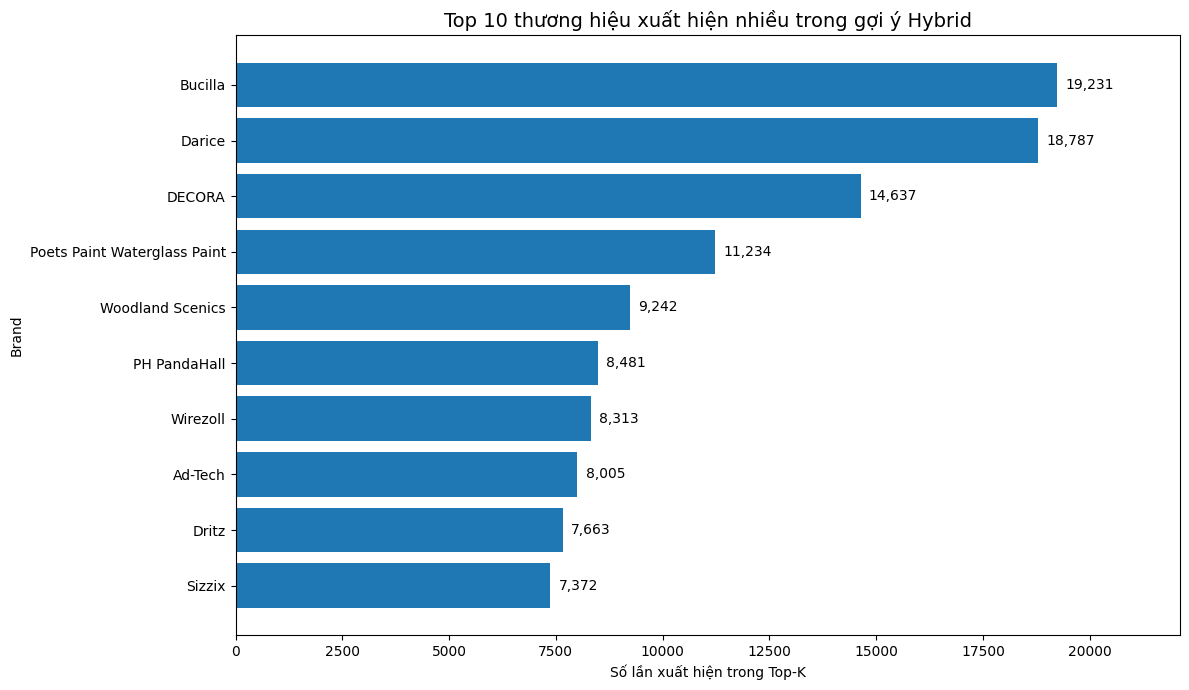

Đã lưu biểu đồ: /content/drive/MyDrive/ALS_Hybrid_Recommendation/data/results/charts/top_brand_hybrid_recommendations.png


In [ ]:
top_brand_recs = topk_hybrid.groupBy("brand").count() \
    .orderBy(desc("count")) \
    .limit(10) \
    .toPandas()

display(top_brand_recs)

top_brand_recs = top_brand_recs.sort_values("count", ascending=True)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    top_brand_recs["brand"],
    top_brand_recs["count"]
)

plt.title("Top 10 thương hiệu xuất hiện nhiều trong gợi ý Hybrid", fontsize=14)
plt.xlabel("Số lần xuất hiện trong Top-K")
plt.ylabel("Brand")

max_value = top_brand_recs["count"].max()
plt.xlim(0, max_value * 1.15)

for bar, value in zip(bars, top_brand_recs["count"]):
    plt.text(
        bar.get_width() + max_value * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,}",
        va="center",
        fontsize=10
    )

plt.tight_layout()

top_brand_chart_path = charts_path + "/top_brand_hybrid_recommendations.png"
plt.savefig(top_brand_chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Đã lưu biểu đồ:", top_brand_chart_path)

# **20. Cold-start fallback**

20.1. Cold-start fallback bằng sản phẩm phổ biến

In [ ]:
# Kiểm tra và thêm category_str cho train_cached nếu chưa có
if "category_str" not in train_cached.columns:
    train_cached = train_cached.withColumn(
        "category_str",
        concat_ws(" > ", col("category"))
    ).cache()

popular_items = train_cached.groupBy(
    "itemIndex",
    "asin",
    "title",
    "brand",
    "category_str"
).agg(
    avg("rating").alias("global_avg_rating"),
    count("*").alias("interaction_count")
)

popular_items = popular_items.filter(
    col("interaction_count") >= 5
).withColumn(
    "fallback_score",
    col("global_avg_rating") * col("interaction_count")
).withColumn(
    "fallback_type",
    lit("new_user_popular_items")
).orderBy(
    desc("fallback_score"),
    desc("global_avg_rating"),
    desc("interaction_count")
)

print("Top sản phẩm phổ biến dùng cho Cold-start user mới:")
popular_items.show(20, truncate=False)

Top sản phẩm phổ biến dùng cho Cold-start user mới:
+---------+----------+------------------------------------------------------------------------------------------------------------------------------------------+------------------+----------------------------------------------------------------------------------------------------+-----------------+-----------------+------------------+----------------------+
|itemIndex|asin      |title                                                                                                                                     |brand             |category_str                                                                                        |global_avg_rating|interaction_count|fallback_score    |fallback_type         |
+---------+----------+------------------------------------------------------------------------------------------------------------------------------------------+------------------+------------------------------------------------

20.2. Lưu Cold-start fallback

In [ ]:
popular_items.write.mode("overwrite").parquet(cold_start_path)

print("Đã lưu Cold-start fallback tại:", cold_start_path)

Đã lưu Cold-start fallback tại: /content/drive/MyDrive/ALS_Hybrid_Recommendation/data/results/cold_start_fallback_parquet


20.3. Cold-start fallback theo brand và category

In [ ]:
# Loại brand/category rỗng trước khi tạo fallback
train_for_fallback = train_cached.filter(
    (col("brand").isNotNull()) &
    (col("brand") != "") &
    (col("brand") != "Unknown brand") &
    (col("category_str").isNotNull()) &
    (col("category_str") != "") &
    (col("category_str") != "Unknown category")
)

popular_by_brand = train_for_fallback.groupBy(
    "brand",
    "itemIndex",
    "asin",
    "title",
    "category_str"
).agg(
    avg("rating").alias("brand_avg_rating"),
    count("*").alias("interaction_count")
).filter(
    col("interaction_count") >= 3
).withColumn(
    "brand_fallback_score",
    col("brand_avg_rating") * col("interaction_count")
).orderBy(
    "brand",
    desc("brand_avg_rating"),
    desc("interaction_count")
)

popular_by_category = train_for_fallback.groupBy(
    "category_str",
    "itemIndex",
    "asin",
    "title",
    "brand"
).agg(
    avg("rating").alias("category_avg_rating"),
    count("*").alias("interaction_count")
).filter(
    col("interaction_count") >= 3
).withColumn(
    "category_fallback_score",
    col("category_avg_rating") * col("interaction_count")
).orderBy(
    "category_str",
    desc("category_avg_rating"),
    desc("interaction_count")
)

popular_by_brand.write.mode("overwrite").parquet(popular_by_brand_path)
popular_by_category.write.mode("overwrite").parquet(popular_by_category_path)

print("Đã lưu fallback theo brand:", popular_by_brand_path)
print("Đã lưu fallback theo category:", popular_by_category_path)

print("Fallback theo brand:")
popular_by_brand.show(10, truncate=False)

print("Fallback theo category:")
popular_by_category.show(10, truncate=False)

Đã lưu fallback theo brand: /content/drive/MyDrive/ALS_Hybrid_Recommendation/data/results/cold_start_by_brand_parquet
Đã lưu fallback theo category: /content/drive/MyDrive/ALS_Hybrid_Recommendation/data/results/cold_start_by_category_parquet
Fallback theo brand:
+---------------+---------+----------+-------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------+-----------------+-----------------+--------------------+
|brand          |itemIndex|asin      |title                                                                                                                                                  |category_str                                                                                  |brand_avg_rating |interaction_count|brand_fallback_score|
+---------------+---------+----------+-------------

20.4. Xem gợi ý cho một user cụ thể

In [ ]:
# Nếu topk_hybrid chưa có các cột clamped thì sẽ được tạo thêm
if "als_score_clamped" not in topk_hybrid.columns:
    topk_hybrid = topk_hybrid.withColumn(
        "als_score_clamped",
        when(col("als_score") < 1.0, 1.0)
        .when(col("als_score") > 5.0, 5.0)
        .otherwise(col("als_score"))
    )

if "content_score_clamped" not in topk_hybrid.columns:
    topk_hybrid = topk_hybrid.withColumn(
        "content_score_clamped",
        when(col("content_score") < 1.0, 1.0)
        .when(col("content_score") > 5.0, 5.0)
        .otherwise(col("content_score"))
    )

# Tính lại hybrid_score theo điểm đã clamp để đảm bảo nằm trong thang 1 -> 5
topk_hybrid = topk_hybrid.withColumn(
    "hybrid_score_clamped",
    lit(best_alpha) * col("als_score_clamped")
    + lit(1 - best_alpha) * col("content_score_clamped")
)

# Clamp lại lần nữa
topk_hybrid = topk_hybrid.withColumn(
    "hybrid_score_clamped",
    when(col("hybrid_score_clamped") < 1.0, 1.0)
    .when(col("hybrid_score_clamped") > 5.0, 5.0)
    .otherwise(col("hybrid_score_clamped"))
)

In [ ]:
# Chọn 1 user demo
demo_user = topk_hybrid.select(
    "userIndex",
    "reviewerID"
).dropna().limit(1).collect()[0]

demo_user_index = demo_user["userIndex"]
demo_reviewer_id = demo_user["reviewerID"]

print("User demo:", demo_reviewer_id)
print("User index:", demo_user_index)

# Hiển thị Top 10 sản phẩm Hybrid gợi ý cho user demo
topk_hybrid.filter(
    col("userIndex") == demo_user_index
).select(
    "rank",
    "asin",
    "title",
    "brand",
    "als_score",
    "als_score_clamped",
    "content_score",
    "content_score_clamped",
    "hybrid_score",
    "hybrid_score_clamped"
).orderBy("rank").show(truncate=False)

User demo: A3NDWL56CCM3Q5
User index: 1
+----+----------+-------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+---------+-----------------+------------------+---------------------+-----------------+--------------------+
|rank|asin      |title                                                                                                                                                        |brand             |als_score|als_score_clamped|content_score     |content_score_clamped|hybrid_score     |hybrid_score_clamped|
+----+----------+-------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+---------+-----------------+------------------+---------------------+-----------------+--------------------+
|1   |B00F6P9RQM|Housweety 20 Rhinestone Dragonfly 

# **21. Tổng hợp kết quả thực nghiệm**

In [ ]:
summary_results = pd.DataFrame({
    "Nội dung đánh giá": [
        "Thời gian đọc JSON",
        "Thời gian đọc Parquet",
        "Dung lượng JSON.GZ",
        "Dung lượng Parquet",
        "Thời gian train ALS không cache",
        "Thời gian train ALS có cache",
        "RMSE ALS",
        "RMSE Hybrid",
        "Best alpha Hybrid"
    ],
    "Kết quả": [
        f"{json_time:.3f} giây",
        f"{parquet_time:.3f} giây",
        f"{json_size_mb:.2f} MB",
        f"{parquet_size_mb:.2f} MB",
        f"{als_no_cache_time:.3f} giây",
        f"{als_cache_time:.3f} giây",
        round(rmse_als_test, 4),
        round(rmse_hybrid_test, 4),
        best_alpha
    ]
})

display(summary_results)

summary_csv_path = results_path + "/summary_results.csv"
summary_results.to_csv(summary_csv_path, index=False)

print("Đã lưu bảng tổng hợp:", summary_csv_path)

,Nội dung đánh giá,Kết quả
0,Thời gian đọc JSON,3.457 giây
1,Thời gian đọc Parquet,0.756 giây
2,Dung lượng JSON.GZ,51.60 MB
3,Dung lượng Parquet,2.42 MB
4,Thời gian train ALS không cache,46.591 giây
5,Thời gian train ALS có cache,35.685 giây
6,RMSE ALS,1.0517
7,RMSE Hybrid,0.8912
8,Best alpha Hybrid,0.5


Đã lưu bảng tổng hợp: /content/drive/MyDrive/ALS_Hybrid_Recommendation/data/results/summary_results.csv


# **22. Kiểm tra các bảng Parquet đầu ra**

In [ ]:
output_tables = pd.DataFrame({
    "Bảng dữ liệu": [
        "raw_reviews_parquet",
        "raw_meta_parquet",
        "cleaned_interactions_parquet",
        "indexed_interactions_parquet",
        "topk_als_recommendations_parquet",
        "topk_hybrid_recommendations_parquet",
        "cold_start_fallback_parquet",
        "cold_start_by_brand_parquet",
        "cold_start_by_category_parquet"
    ],
    "Đường dẫn": [
        raw_reviews_parquet_path,
        raw_meta_parquet_path,
        cleaned_parquet_path,
        indexed_parquet_path,
        topk_als_path,
        topk_hybrid_path,
        cold_start_path,
        popular_by_brand_path,
        popular_by_category_path
    ]
})

display(output_tables)

,Bảng dữ liệu,Đường dẫn
0,raw_reviews_parquet,/content/drive/MyDrive/ALS_Hybrid_Recommendati...
1,raw_meta_parquet,/content/drive/MyDrive/ALS_Hybrid_Recommendati...
2,cleaned_interactions_parquet,/content/drive/MyDrive/ALS_Hybrid_Recommendati...
3,indexed_interactions_parquet,/content/drive/MyDrive/ALS_Hybrid_Recommendati...
4,topk_als_recommendations_parquet,/content/drive/MyDrive/ALS_Hybrid_Recommendati...
5,topk_hybrid_recommendations_parquet,/content/drive/MyDrive/ALS_Hybrid_Recommendati...
6,cold_start_fallback_parquet,/content/drive/MyDrive/ALS_Hybrid_Recommendati...
7,cold_start_by_brand_parquet,/content/drive/MyDrive/ALS_Hybrid_Recommendati...
8,cold_start_by_category_parquet,/content/drive/MyDrive/ALS_Hybrid_Recommendati...
